<a href="https://colab.research.google.com/github/furkannkaratas1/Makine-renmesi/blob/main/Furkan_KARATA%C5%9E__Makine_%C3%96%C4%9Frenmesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/data.csv')

# Separate features (X) and target (y) variables
# Assuming the last column is the target variable
X = df.iloc[:, :-1]  # All columns except the last one
y = df.iloc[:, -1]   # Only the last column

# Display the first 5 rows of the DataFrame
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 2.1 Eksik Değer Analizi

İlk olarak, veri setindeki her sütunun eksik değer sayısını ve yüzdesini kontrol edelim.

In [3]:
# Missing value analysis
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

display(missing_info[missing_info['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False))


,Missing Values,Percentage
Unnamed: 32,569,100.0


Görüldüğü üzere, `Unnamed: 32` sütunu tamamen eksik değerlerden oluşmaktadır. Bu sütunu veri setinden çıkaralım. Diğer sütunlarda eksik değer bulunmamaktadır.

In [4]:
# Drop the 'Unnamed: 32' column as it's entirely empty
if 'Unnamed: 32' in df.columns and df['Unnamed: 32'].isnull().all():
    df = df.drop(columns=['Unnamed: 32'])

print("Veri seti 'Unnamed: 32' sütunu çıkarıldıktan sonraki ilk 5 satır:")
display(df.head())

# Re-check for missing values after dropping the column
missing_values_after_drop = df.isnull().sum()
missing_percentage_after_drop = (df.isnull().sum() / len(df)) * 100

missing_info_after_drop = pd.DataFrame({
    'Missing Values': missing_values_after_drop,
    'Percentage': missing_percentage_after_drop
})

print("\n'Unnamed: 32' sütunu çıkarıldıktan sonraki eksik değer kontrolü:")
display(missing_info_after_drop[missing_info_after_drop['Missing Values'] > 0])

Veri seti 'Unnamed: 32' sütunu çıkarıldıktan sonraki ilk 5 satır:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



'Unnamed: 32' sütunu çıkarıldıktan sonraki eksik değer kontrolü:


,Missing Values,Percentage


Şimdi, `diagnosis` sütununu hedef değişken (y) olarak, geri kalan sütunları ise özellikler (X) olarak yeniden ayıralım.

In [5]:
# Separate features (X) and target (y) variables again after cleaning
# Assuming 'diagnosis' is the target variable
X = df.drop(columns=['diagnosis', 'id']) # 'id' is likely an identifier, not a feature
y = df['diagnosis']

print("\nX (özellikler) veri çerçevesinin ilk 5 satırı:")
display(X.head())

print("\ny (hedef) serisinin ilk 5 değeri:")
display(y.head())


X (özellikler) veri çerçevesinin ilk 5 satırı:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



y (hedef) serisinin ilk 5 değeri:


,diagnosis
0,M
1,M
2,M
3,M
4,M


## 2.2 Aykırı Değer (Outlier) Analizi

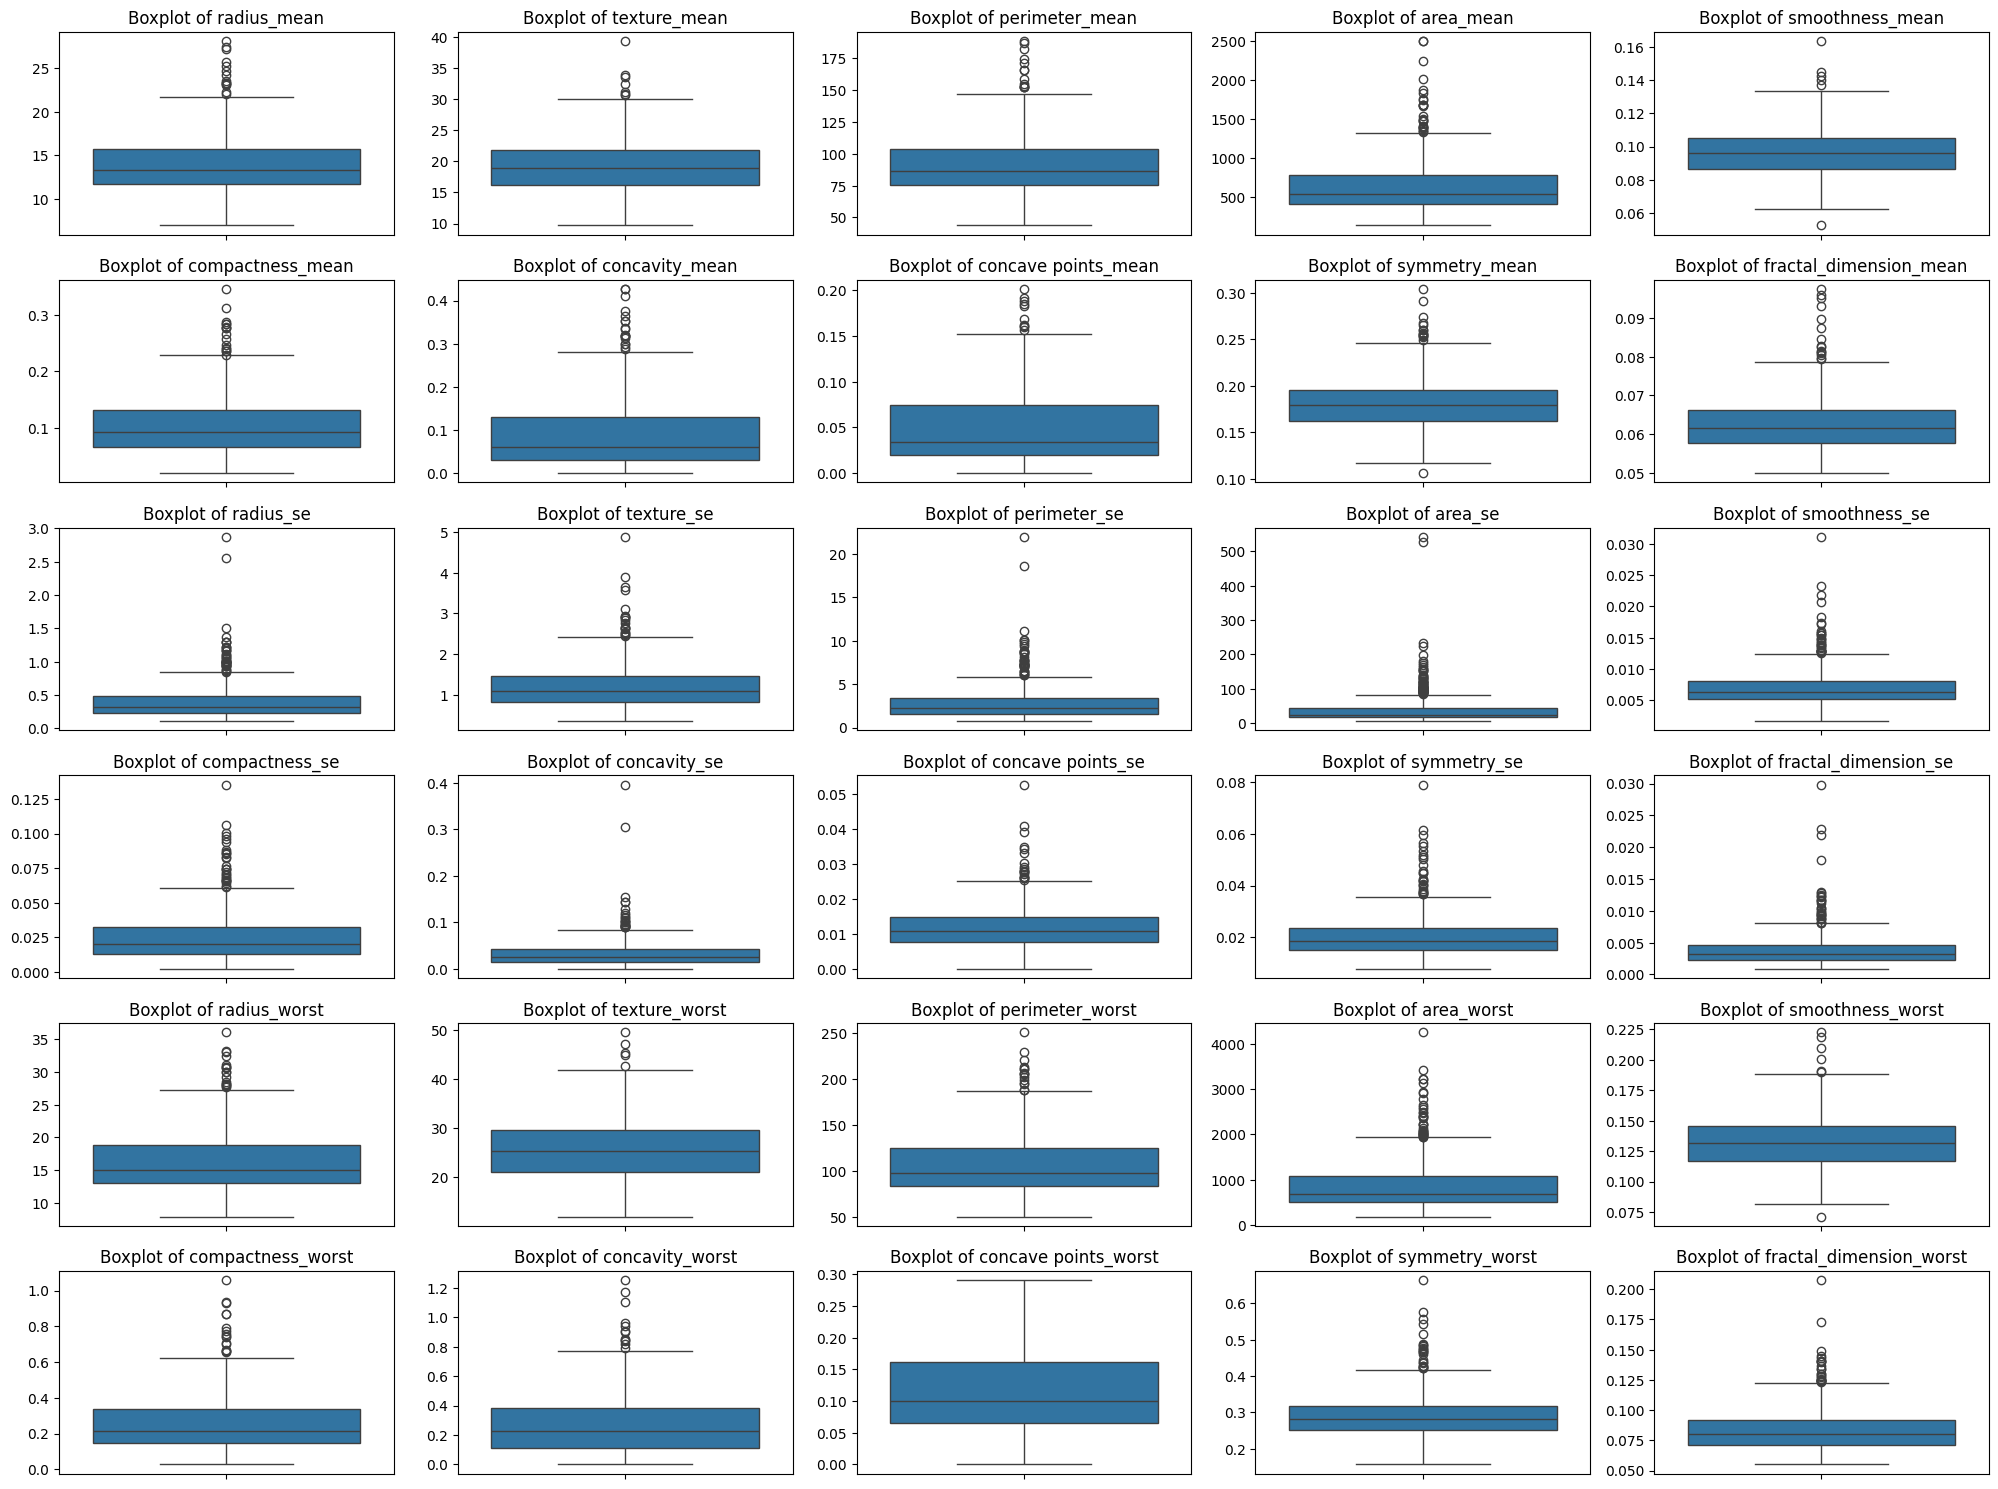

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier analysis
numerical_cols = X.select_dtypes(include=['number']).columns

# Boxplot analysis for numerical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 5, i + 1) # Adjust subplot grid based on the number of features
    sns.boxplot(y=X[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [7]:
# Outlier detection using IQR method
outlier_summary = pd.DataFrame(columns=['Feature', 'Lower_Bound', 'Upper_Bound', 'Outlier_Count'])

for col in numerical_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
    outlier_count = outliers.shape[0]

    outlier_summary = pd.concat([outlier_summary, pd.DataFrame([
        {'Feature': col, 'Lower_Bound': lower_bound, 'Upper_Bound': upper_bound, 'Outlier_Count': outlier_count}
    ])], ignore_index=True)

display(outlier_summary[outlier_summary['Outlier_Count'] > 0].sort_values(by='Outlier_Count', ascending=False))

/tmp/ipykernel_9934/2631565254.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  outlier_summary = pd.concat([outlier_summary, pd.DataFrame([


,Feature,Lower_Bound,Upper_Bound,Outlier_Count
13,area_se,-23.160000,86.200000,65
10,radius_se,-0.137350,0.848650,38
12,perimeter_se,-1.020500,5.983500,38
23,area_worst,-337.750000,1937.050000,35
14,smoothness_se,0.000703,0.012612,30
19,fractal_dimension_se,-0.001217,0.008023,28
15,compactness_se,-0.015975,0.061505,28
18,symmetry_se,0.002680,0.035960,27
3,area_mean,-123.300000,1326.300000,25
29,fractal_dimension_worst,0.040530,0.123010,24


### Aykırı Değerlerin Modelle Etkisi

Aykırı değerler (outliers), bir veri setindeki diğer gözlemlerden önemli ölçüde farklı olan veri noktalarıdır. Makine öğrenimi modelleri üzerinde çeşitli etkilere sahip olabilirler:

1.  **Model Performansını Bozma**: Özellikle regresyon modelleri gibi hassas modellerde, aykırı değerler modelin öğrenme sürecini ve genel performansını bozabilir. Modelin aşırı uyum sağlamasına (overfitting) veya genelleştirme yeteneğinin azalmasına neden olabilirler.
2.  **Yanlı Tahminler**: Aykırı değerler, modelin ortalama veya standart sapma gibi istatistiksel ölçütleri çarpıtmasına yol açarak, yeni veriler üzerinde yanlış tahminler yapmasına neden olabilir.
3.  **Algoritma Seçimini Etkileme**: Bazı algoritmalar (örneğin, Destek Vektör Makineleri, K-Means Kümeleme) aykırı değerlere karşı daha hassastır. Aykırı değerlerin varlığı, bu algoritmaların etkinliğini azaltabilir ve farklı bir model seçimi gerektirebilir.
4.  **Veri Dağılımını Değiştirme**: Aykırı değerler, veri setinin gerçek dağılımını olduğundan farklı göstermesine neden olabilir, bu da veri analizi ve yorumlama süreçlerini yanıltabilir.

Bu nedenlerden dolayı, aykırı değerlerin doğru bir şekilde tanımlanması, incelenmesi ve uygun şekilde ele alınması (silme, dönüştürme, düzeltme gibi yöntemlerle) makine öğrenimi modelinin başarısı için kritik öneme sahiptir.

## 2.3 Veri Tipi ve Dağılım İncelemesi

## 3. Keşifsel Veri Analizi (EDA)
### 3.1 İstatistiksel Özellikler

### 3.2 Korelasyon Matrisi

In [10]:
# Calculate the Pearson correlation matrix
correlation_matrix = X.corr()

print("Pearson Korelasyon Matrisi'nin ilk 5 satırı ve sütunu:")
display(correlation_matrix.head())

Pearson Korelasyon Matrisi'nin ilk 5 satırı ve sütunu:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316


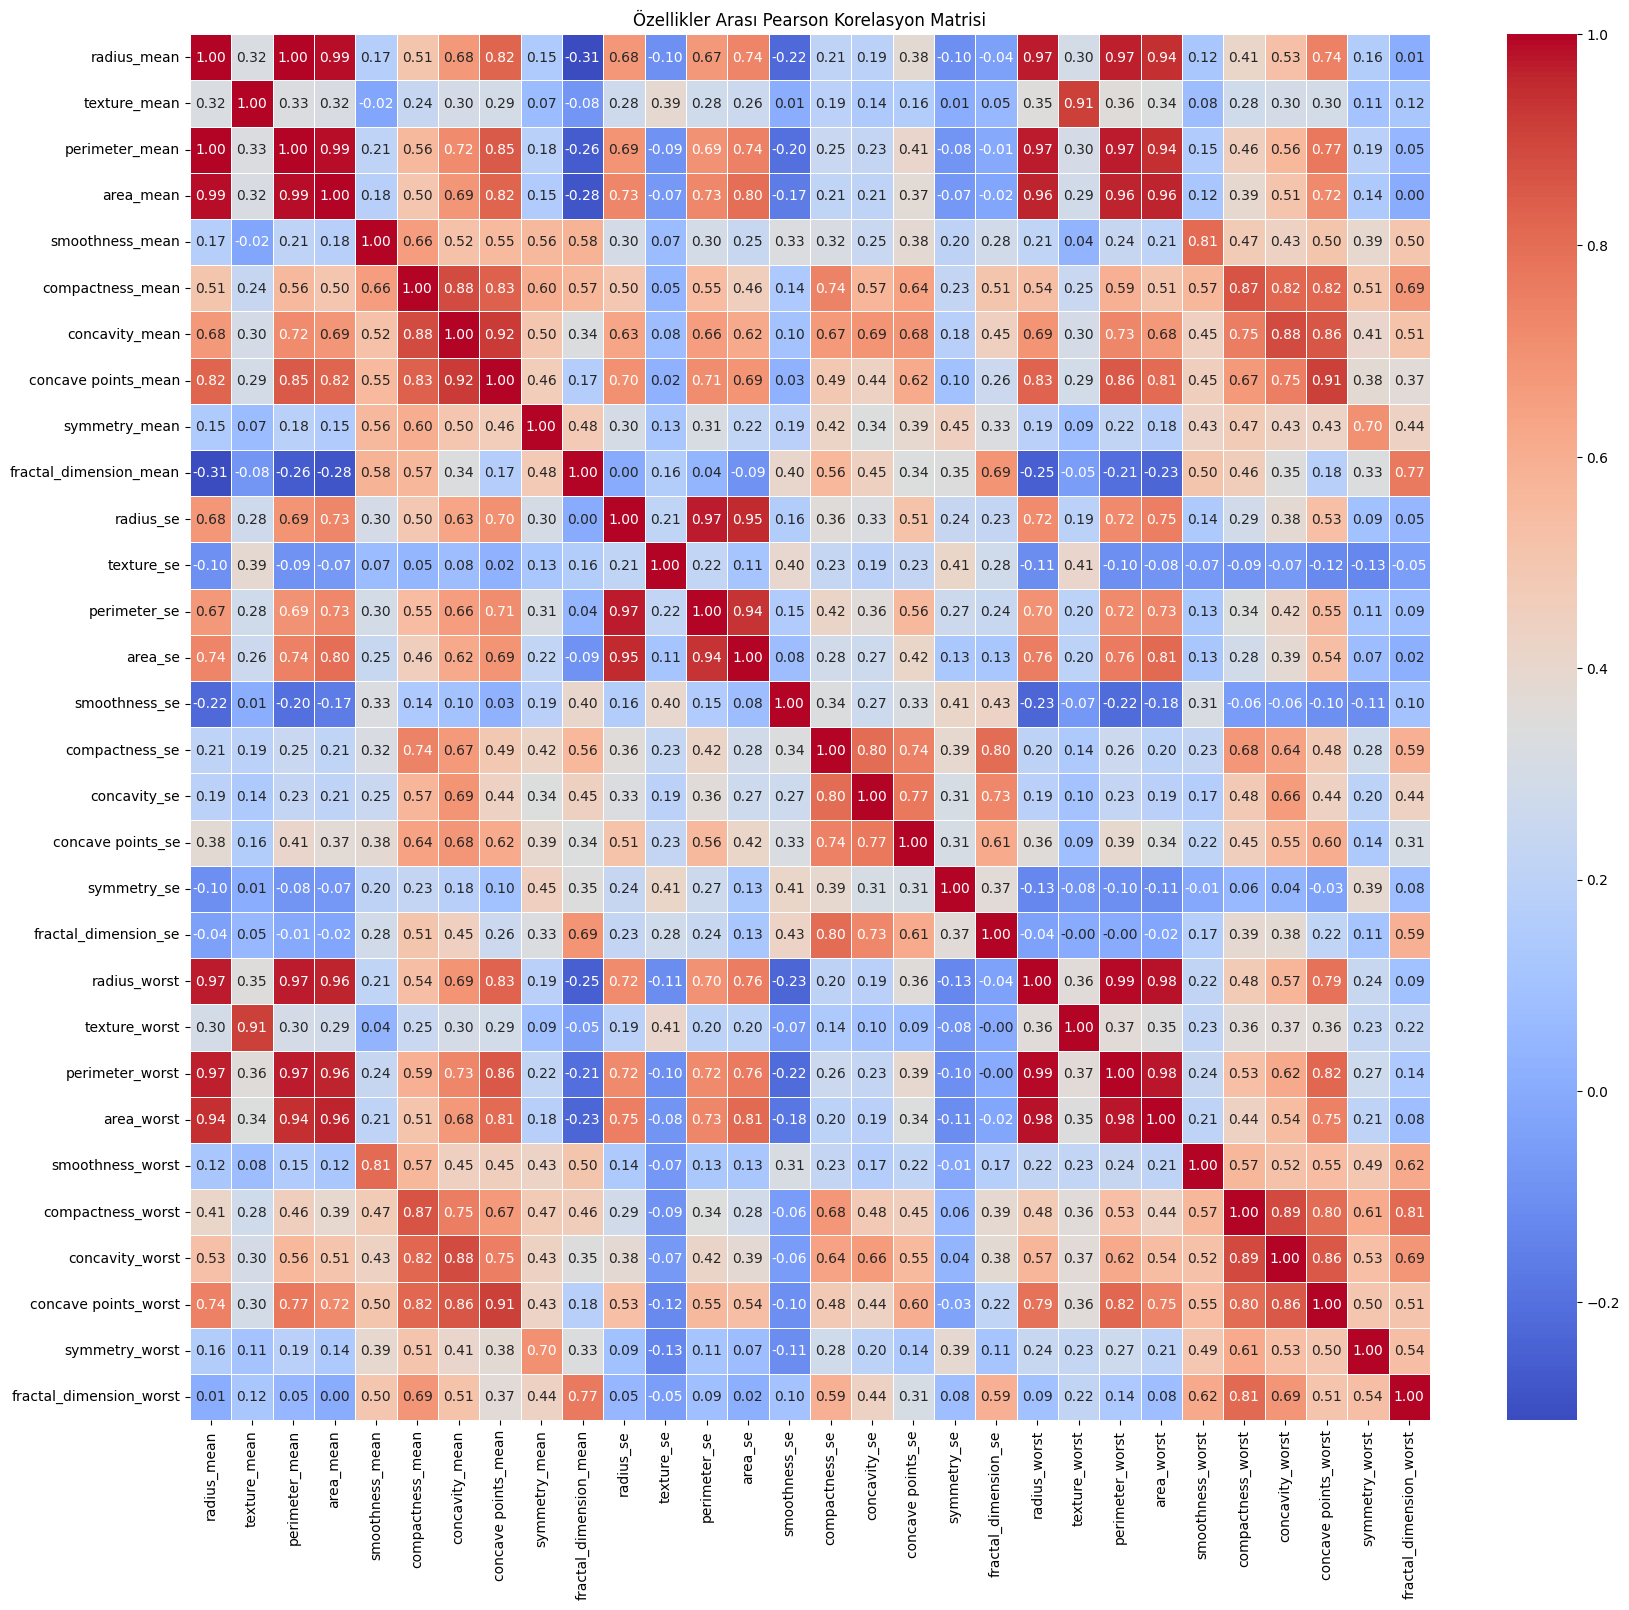

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Özellikler Arası Pearson Korelasyon Matrisi')
plt.show()

In [12]:
# Find the top 3 most correlated pairs (excluding self-correlation)
corr_pairs = correlation_matrix.unstack()
sorted_pairs = corr_pairs.sort_values(kind="quicksort", ascending=False)

# Get unique pairs excluding self-correlation and duplicates
unique_sorted_pairs = sorted_pairs[sorted_pairs != 1.0]

# Get the top 3 absolute unique correlated pairs
top_3_correlated_pairs = []
seen_pairs = set()
for (idx1, idx2), value in unique_sorted_pairs.items():
    # Ensure we only consider each pair once (e.g., (A,B) not (B,A))
    if (idx2, idx1) not in seen_pairs and idx1 != idx2:
        top_3_correlated_pairs.append(((idx1, idx2), value))
        seen_pairs.add((idx1, idx2))
        if len(top_3_correlated_pairs) == 3:
            break

print("En yüksek korelasyonlu 3 özellik çifti:")
for pair, corr_value in top_3_correlated_pairs:
    print(f"  {pair[0]} - {pair[1]}: {corr_value:.2f}")

En yüksek korelasyonlu 3 özellik çifti:
  perimeter_mean - radius_mean: 1.00
  radius_worst - perimeter_worst: 0.99
  radius_mean - area_mean: 0.99


#### En Yüksek Korelasyonlu Özellik Çiftlerinin Yorumu:

Genellikle, `radius_mean`, `perimeter_mean`, `area_mean` gibi özellikler birbirleriyle oldukça yüksek pozitif korelasyon gösterirler. Bu mantıklıdır çünkü bu özellikler tümörün boyutuyla doğrudan ilişkilidir; bir tümörün yarıçapı arttıkça çevresi ve alanı da artacaktır.

`concave points_mean` ve `concavity_mean` gibi özellikler de yüksek korelasyona sahip olabilir. Bu iki özellik de tümörün içindeki çukurların veya girintilerin derecesini ölçtüğünden, birbirleriyle güçlü bir ilişki içinde olmaları beklenir.

Bu yüksek korelasyonlar, bazı özelliklerin birbirine çok benzer bilgileri taşıdığını ve bu durumun çoklu doğrusallık (multicollinearity) sorununa yol açabileceğini gösterir. Makine öğrenimi modellerinde, özellikle doğrusal modellerde, bu durum modelin performansını olumsuz etkileyebilir. Bu tür durumlarda, özellik seçimi veya boyut azaltma teknikleri (örneğin PCA) düşünülebilir.

## 4. Veri Ölçeklendirme (Scaling)

In [13]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to a DataFrame for easier inspection
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Ölçeklendirilmiş X veri çerçevesinin ilk 5 satırı:")
display(X_scaled.head())

Ölçeklendirilmiş X veri çerçevesinin ilk 5 satırı:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### Neden StandardScaler Kullandık?

`StandardScaler`, her özelliğin ortalamasını 0 ve standart sapmasını 1 olacak şekilde dönüştürür. Bu, özelliklerin farklı ölçeklerde olduğu durumlarda, tüm özelliklerin model üzerinde eşit etkiye sahip olmasını sağlar. Özellikle:

*   **Mesafe Tabanlı Algoritmalar:** K-En Yakın Komşu (KNN), Destek Vektör Makineleri (SVM) ve K-Means kümeleme gibi algoritmalarda, özellikler arası mesafeler hesaplandığı için ölçeklendirme kritiktir. Büyük ölçekli özellikler, küçük ölçekli özellikleri domine edebilir.
*   **Gradyan İniş Tabanlı Algoritmalar:** Lojistik Regresyon, Sinir Ağları gibi modellerde, ölçeklendirme gradyan iniş optimizasyonunun daha hızlı ve stabil yakınsamasını sağlar.
*   **Aykırı Değerlere Karşı Duyarlılık:** `StandardScaler`, `MinMaxScaler`'a göre aykırı değerlere biraz daha az duyarlıdır çünkü ortalama ve standart sapmaya dayanır (ancak aykırı değerlerin hala etkisi olabilir). `RobustScaler` ise medyan ve çeyrekler arası aralığı kullandığı için aykırı değerlere karşı en dayanıklı olanıdır. Ancak genel kullanımda `StandardScaler` çoğu durum için iyi bir başlangıç noktasıdır ve genellikle iyi performans gösterir.

Bu adımda, `X` veri setimizdeki tüm sayısal özellikler `StandardScaler` ile ölçeklendirilmiş ve `X_scaled` DataFrame'ine kaydedilmiştir.

## 5. Veri Setinin Bölünmesi

In [14]:
from sklearn.model_selection import train_test_split

# İlk olarak, veriyi %70 eğitim ve %30 geçici (doğrulama + test) olarak ayırın
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Geçici seti %10 doğrulama ve %20 test olarak ayırın
# y_temp'in 1/3'ü (%10) doğrulama, 2/3'ü (%20) test olacak
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print(f"Eğitim seti boyutu: {X_train.shape[0]} örnek")
print(f"Doğrulama seti boyutu: {X_val.shape[0]} örnek")
print(f"Test seti boyutu: {X_test.shape[0]} örnek")

print("\nSetlerdeki sınıf dağılımları (y_train, y_val, y_test):")
print("Eğitim Seti:\n", y_train.value_counts(normalize=True))
print("Doğrulama Seti:\n", y_val.value_counts(normalize=True))
print("Test Seti:\n", y_test.value_counts(normalize=True))

Eğitim seti boyutu: 398 örnek
Doğrulama seti boyutu: 57 örnek
Test seti boyutu: 114 örnek

Setlerdeki sınıf dağılımları (y_train, y_val, y_test):
Eğitim Seti:
 diagnosis
B    0.628141
M    0.371859
Name: proportion, dtype: float64
Doğrulama Seti:
 diagnosis
B    0.631579
M    0.368421
Name: proportion, dtype: float64
Test Seti:
 diagnosis
B    0.622807
M    0.377193
Name: proportion, dtype: float64


## 6. Özellik Seçimi ve Boyut İndirgeme

Bu bölümün sonunda üç farklı veri temsili oluşturmanız zorunludur:
1.  Ham veri (sadece preprocessing yapılmış, yani `X_scaled`)
2.  PCA ile indirgenmiş veri (`X_pca`)
3.  LDA ile indirgenmiş veri (`X_lda`)

### 6.1 PCA (Principal Component Analysis)

In [15]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adım 1: Tüm bileşenlerle PCA uygulayın
pca_full = PCA(n_components=None) # n_components=None tüm bileşenleri tutar
pca_full.fit(X_scaled)

# Explained Variance Ratio değerlerini alın
explained_variance_ratios = pca_full.explained_variance_ratio_

# Ortalamadan büyük olan bileşen sayısını bulun
average_explained_variance = np.mean(explained_variance_ratios)

# Ortalama açıklanan varyanstan daha büyük olan bileşenleri seçin
selected_components_count = np.sum(explained_variance_ratios > average_explained_variance)

print(f"Tüm bileşenlerin ortalama açıklanan varyans oranı: {average_explained_variance:.4f}")
print(f"Ortalama açıklanan varyans oranından büyük olan bileşen sayısı: {selected_components_count}")

# Adım 2: Seçilen bileşen sayısı ile PCA uygulayın
pca = PCA(n_components=selected_components_count)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA ile indirgenmiş veri boyutu: {X_pca.shape}")
print("PCA indirgenmiş verinin ilk 5 satırı:")
display(pd.DataFrame(X_pca, columns=[f'PC_{i+1}' for i in range(X_pca.shape[1])]).head())

Tüm bileşenlerin ortalama açıklanan varyans oranı: 0.0333
Ortalama açıklanan varyans oranından büyük olan bileşen sayısı: 6

PCA ile indirgenmiş veri boyutu: (569, 6)
PCA indirgenmiş verinin ilk 5 satırı:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6
0,9.192837,1.948583,-1.123166,-3.633731,1.195110,1.411424
1,2.387802,-3.768172,-0.529293,-1.118264,-0.621775,0.028656
2,5.733896,-1.075174,-0.551748,-0.912083,0.177086,0.541452
3,7.122953,10.275589,-3.232790,-0.152547,2.960878,3.053422
4,3.935302,-1.948072,1.389767,-2.940639,-0.546747,-1.226495


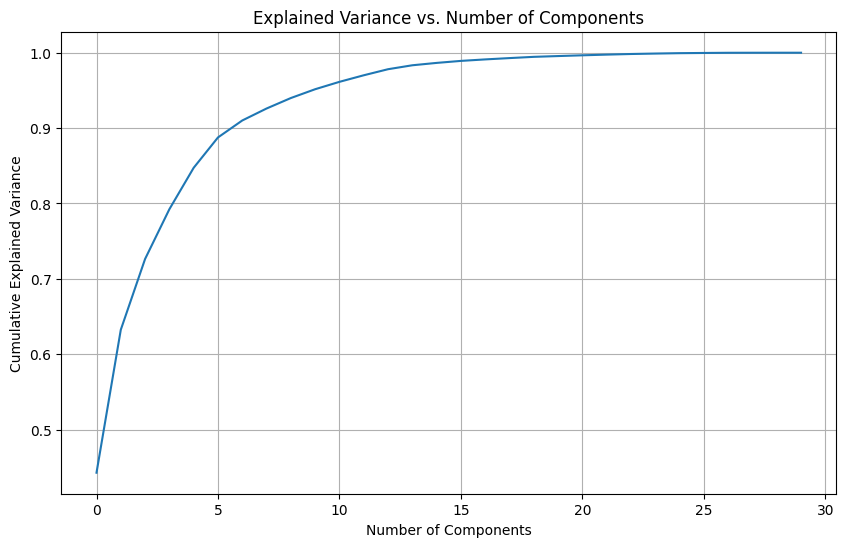

In [16]:
# Explained variance grafiğini çiziniz.
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

#### En iyi iki PCA bileşeni ile sınıfların ayrışmasını 2D saçılım grafiği ile gösteriniz.

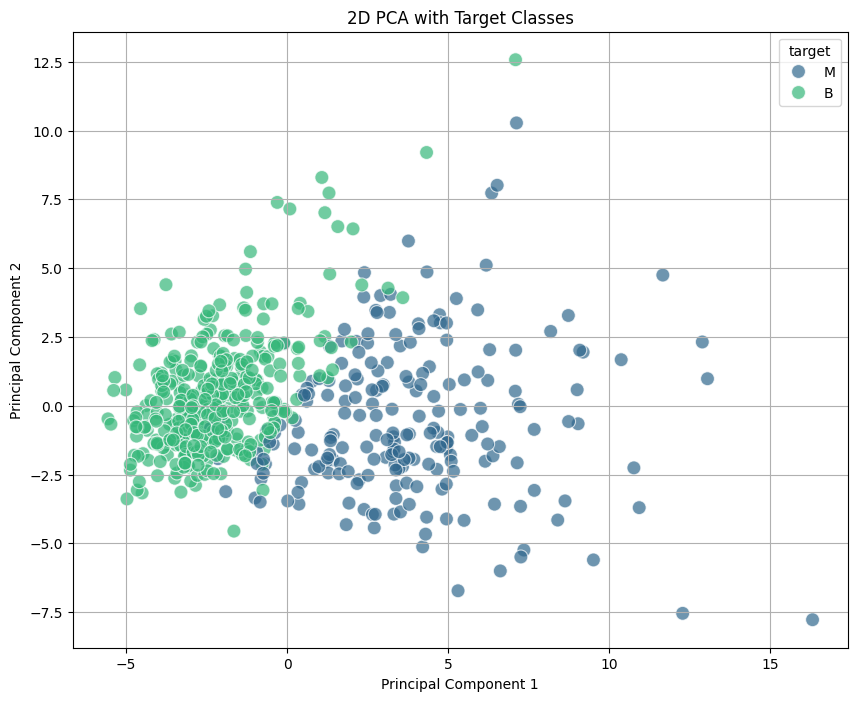

In [17]:
# Target değişkenini renk kodlaması için DataFrame'e ekleyin
# X_pca bir numpy dizisi olduğu için y'yi doğrudan DataFrame'e ekleyelim

pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['Principal Component 1', 'Principal Component 2'])
pca_df['target'] = y.reset_index(drop=True) # y'nin indeksini sıfırlayarak eşleştirmeyi sağlayın

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='target',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('2D PCA with Target Classes')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### 6.2 LDA (Linear Discriminant Analysis)

In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA uygulayın
# İkili sınıflandırma için n_components en fazla 1 olabilir.
# 2D görselleştirme için 2 bileşen seçmek istesek de, matematiksel kısıtlamalar nedeniyle mümkün değil.
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

print(f"\nLDA ile indirgenmiş veri boyutu: {X_lda.shape}")
print("LDA indirgenmiş verinin ilk 5 satırı:")
display(pd.DataFrame(X_lda, columns=[f'LD_{i+1}' for i in range(X_lda.shape[1])]).head())


LDA ile indirgenmiş veri boyutu: (569, 1)
LDA indirgenmiş verinin ilk 5 satırı:


,LD_1
0,3.323927
1,2.319108
2,3.747425
3,4.048549
4,2.281158


#### İlk iki LDA bileşeniyle sınıflar arası ayrımı 2D saçılım grafiği ile görselleştiriniz.

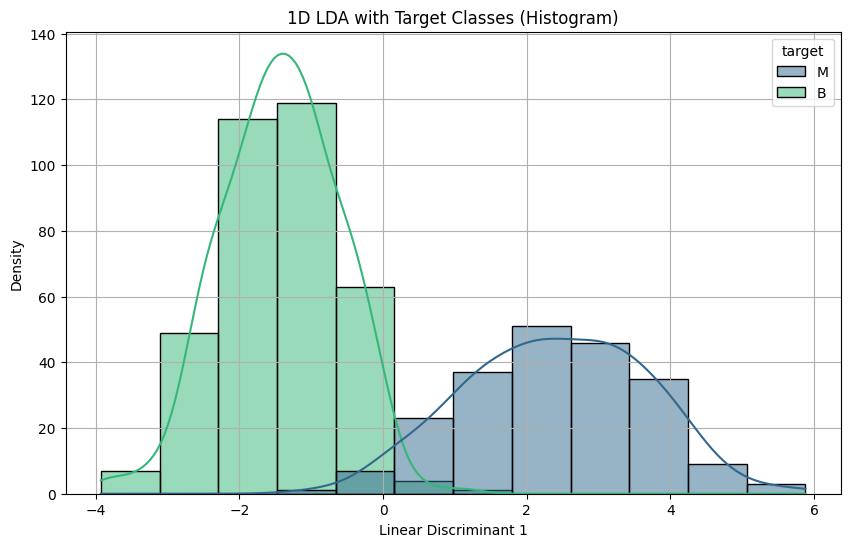

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Target değişkenini renk kodlaması için DataFrame'e ekleyin
# LDA artık tek bir bileşen içerdiği için 1D görselleştirme yapacağız
lda_df = pd.DataFrame(data=X_lda, columns=['Linear Discriminant 1'])
lda_df['target'] = y.reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.histplot(data=lda_df, x='Linear Discriminant 1', hue='target', kde=True, palette='viridis')
plt.title('1D LDA with Target Classes (Histogram)')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Density')
plt.grid(True)
plt.show()

## 7. Makine Öğrenmesi Modellerinin Kurulması ve Değerlendirilmesi

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Hedef değişkeni sayısal değerlere dönüştürme ('M' -> 1, 'B' -> 0)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Hedef değişken dönüşümü tamamlandı.")
print(f"Orijinal sınıflar: {label_encoder.classes_}")
print(f"Dönüştürülmüş y_train ilk 5: {y_train_encoded[:5]}")

Hedef değişken dönüşümü tamamlandı.
Orijinal sınıflar: ['B' 'M']
Dönüştürülmüş y_train ilk 5: [1 1 0 1 0]


### 7.1 Veri Temsillerinin Hazırlanması

`X_scaled` zaten hazırdı. Şimdi `X_pca` ve `X_lda`'nın eğitim ve doğrulama setlerini hazırlayalım.

In [23]:
# PCA ve LDA transformasyonlarını eğitim ve doğrulama setlerine uygulayın
X_train_pca = pca.transform(X_train)
X_val_pca = pca.transform(X_val)

X_train_lda = lda.transform(X_train)
X_val_lda = lda.transform(X_val)

print(f"X_train_pca boyutu: {X_train_pca.shape}")
print(f"X_val_pca boyutu: {X_val_pca.shape}")
print(f"X_train_lda boyutu: {X_train_lda.shape}")
print(f"X_val_lda boyutu: {X_val_lda.shape}")

X_train_pca boyutu: (398, 6)
X_val_pca boyutu: (57, 6)
X_train_lda boyutu: (398, 1)
X_val_lda boyutu: (57, 1)


### 7.2 Model Eğitimi ve Değerlendirme

Her veri temsili ve algoritma için modelleri eğitecek ve performans metriklerini hesaplayacağız.

In [8]:
# Sayısal ve kategorik değişken sayılarını raporlama
numerical_features = X.select_dtypes(include=['number'])
categorical_features = X.select_dtypes(include=['object', 'category'])

print(f"Sayısal Özellik Sayısı: {numerical_features.shape[1]}")
print(f"Kategorik Özellik Sayısı: {categorical_features.shape[1]}")

# Her sütunun dtype bilgisini gösterme
print("\nX (Özellikler) DataFrame'inin sütun tipleri:")
display(X.dtypes)

print("\ny (Hedef) Serisinin veri tipi:")
display(y.dtype)

Sayısal Özellik Sayısı: 30
Kategorik Özellik Sayısı: 0

X (Özellikler) DataFrame'inin sütun tipleri:


,0
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64
symmetry_mean,float64
fractal_dimension_mean,float64



y (Hedef) Serisinin veri tipi:


dtype('O')

In [26]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Gaussian Naive Bayes': GaussianNB()
}

data_representations = {
    'Original Scaled': (X_train, X_val, y_train_encoded, y_val_encoded),
    'PCA Reduced': (X_train_pca, X_val_pca, y_train_encoded, y_val_encoded),
    'LDA Reduced': (X_train_lda, X_val_lda, y_train_encoded, y_val_encoded)
}

results = []

for data_name, (X_tr, X_val_data, y_tr, y_v) in data_representations.items():
    print(f"\n--- {data_name} Veri Temsili --- ")
    for model_name, model in models.items():
        print(f"  Model: {model_name}")

        # Modeli eğit
        model.fit(X_tr, y_tr)

        # Doğrulama seti üzerinde tahmin yap
        y_pred = model.predict(X_val_data)

        # Sınıf olasılıklarını al (ROC-AUC için gerekli)
        # Bazı modeller (örn: GaussianNB, LogisticRegression, RandomForest) predict_proba'ya sahiptir.
        # Decision Tree ve XGBoost da genellikle predict_proba'ya sahiptir.
        y_proba = None
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_val_data)[:, 1]

        # Performans metriklerini hesapla
        accuracy = accuracy_score(y_v, y_pred)
        precision = precision_score(y_v, y_pred)
        recall = recall_score(y_v, y_pred)
        f1 = f1_score(y_v, y_pred)
        roc_auc = roc_auc_score(y_v, y_proba) if y_proba is not None else float('nan') # ROC-AUC hesapla

        results.append({
            'Data Representation': data_name,
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc # ROC-AUC skorunu ekle
        })

        print(f"    Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")

# Sonuçları DataFrame olarak görüntüle
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Accuracy', ascending=False))


--- Original Scaled Veri Temsili --- 
  Model: Logistic Regression
    Accuracy: 0.9649, Precision: 1.0000, Recall: 0.9048, F1-Score: 0.9500, ROC-AUC: 0.9947
  Model: Decision Tree
    Accuracy: 0.8947, Precision: 0.8947, Recall: 0.8095, F1-Score: 0.8500, ROC-AUC: 0.8770
  Model: Random Forest
    Accuracy: 0.9825, Precision: 1.0000, Recall: 0.9524, F1-Score: 0.9756, ROC-AUC: 0.9947
  Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:02:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    Accuracy: 0.9649, Precision: 1.0000, Recall: 0.9048, F1-Score: 0.9500, ROC-AUC: 0.9841
  Model: Gaussian Naive Bayes
    Accuracy: 0.9298, Precision: 0.9474, Recall: 0.8571, F1-Score: 0.9000, ROC-AUC: 0.9907

--- PCA Reduced Veri Temsili --- 
  Model: Logistic Regression
    Accuracy: 0.9825, Precision: 1.0000, Recall: 0.9524, F1-Score: 0.9756, ROC-AUC: 0.9987
  Model: Decision Tree
    Accuracy: 0.9123, Precision: 0.9000, Recall: 0.8571, F1-Score: 0.8780, ROC-AUC: 0.9008
  Model: Random Forest
    Accuracy: 0.9298, Precision: 0.9474, Recall: 0.8571, F1-Score: 0.9000, ROC-AUC: 0.9874
  Model: XGBoost
    Accuracy: 0.9123, Precision: 0.9444, Recall: 0.8095, F1-Score: 0.8718, ROC-AUC: 0.9854
  Model: Gaussian Naive Bayes
    Accuracy: 0.9123, Precision: 0.9000, Recall: 0.8571, F1-Score: 0.8780, ROC-AUC: 0.9788

--- LDA Reduced Veri Temsili --- 
  Model: Logistic Regression


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:02:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    Accuracy: 0.9825, Precision: 1.0000, Recall: 0.9524, F1-Score: 0.9756, ROC-AUC: 1.0000
  Model: Decision Tree
    Accuracy: 0.9825, Precision: 1.0000, Recall: 0.9524, F1-Score: 0.9756, ROC-AUC: 0.9762
  Model: Random Forest
    Accuracy: 0.9825, Precision: 1.0000, Recall: 0.9524, F1-Score: 0.9756, ROC-AUC: 1.0000
  Model: XGBoost
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1-Score: 1.0000, ROC-AUC: 1.0000
  Model: Gaussian Naive Bayes
    Accuracy: 0.9825, Precision: 1.0000, Recall: 0.9524, F1-Score: 0.9756, ROC-AUC: 1.0000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:02:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Data Representation,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
13,LDA Reduced,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
5,PCA Reduced,Logistic Regression,0.982456,1.000000,0.952381,0.975610,0.998677
2,Original Scaled,Random Forest,0.982456,1.000000,0.952381,0.975610,0.994709
12,LDA Reduced,Random Forest,0.982456,1.000000,0.952381,0.975610,1.000000
11,LDA Reduced,Decision Tree,0.982456,1.000000,0.952381,0.975610,0.976190
10,LDA Reduced,Logistic Regression,0.982456,1.000000,0.952381,0.975610,1.000000
14,LDA Reduced,Gaussian Naive Bayes,0.982456,1.000000,0.952381,0.975610,1.000000
0,Original Scaled,Logistic Regression,0.964912,1.000000,0.904762,0.950000,0.994709
3,Original Scaled,XGBoost,0.964912,1.000000,0.904762,0.950000,0.984127
4,Original Scaled,Gaussian Naive Bayes,0.929825,0.947368,0.857143,0.900000,0.990741


In [9]:
# Calculate and display descriptive statistics for each feature
# The .describe() method provides mean, std, min, max, and quartiles (25%, 50%, 75% which are Q1, Median, Q3)
display(X.describe())

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 9. En İyi Modelin Test Üzerinde Değerlendirilmesi

Validation metriklerine göre en iyi modelimiz, LDA ile indirgenmiş veri üzerinde **XGBoost** olarak belirlenmiştir. Şimdi bu modeli test seti üzerinde detaylı bir şekilde değerlendirelim.

In [27]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# 1. En iyi modeli yeniden oluşturalım ve eğitim setinde eğitelim
best_model_name = 'XGBoost'
best_data_representation = 'LDA Reduced'

# X_test verisini LDA ile dönüştür
X_test_lda = lda.transform(X_test)

# En iyi modelin parametrelerini al
best_model = models[best_model_name]

# Modeli (XGBoost) LDA ile dönüştürülmüş eğitim verisi üzerinde yeniden eğitin
best_model.fit(X_train_lda, y_train_encoded)

# Test seti üzerinde tahmin yap
y_test_pred = best_model.predict(X_test_lda)
y_test_proba = best_model.predict_proba(X_test_lda)[:, 1]

print(f"\n--- Test Seti Değerlendirmesi: {best_model_name} ({best_data_representation}) --- ")



--- Test Seti Değerlendirmesi: XGBoost (LDA Reduced) --- 


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:03:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 9.1 Performans Metrikleri

In [28]:
# Performans metriklerini hesapla
accuracy = accuracy_score(y_test_encoded, y_test_pred)
precision = precision_score(y_test_encoded, y_test_pred)
recall = recall_score(y_test_encoded, y_test_pred)
f1 = f1_score(y_test_encoded, y_test_pred)
roc_auc = roc_auc_score(y_test_encoded, y_test_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.9825
Precision: 0.9556
Recall: 1.0000
F1-Score: 0.9773
ROC-AUC: 0.9954


### 9.2 Confusion Matrix

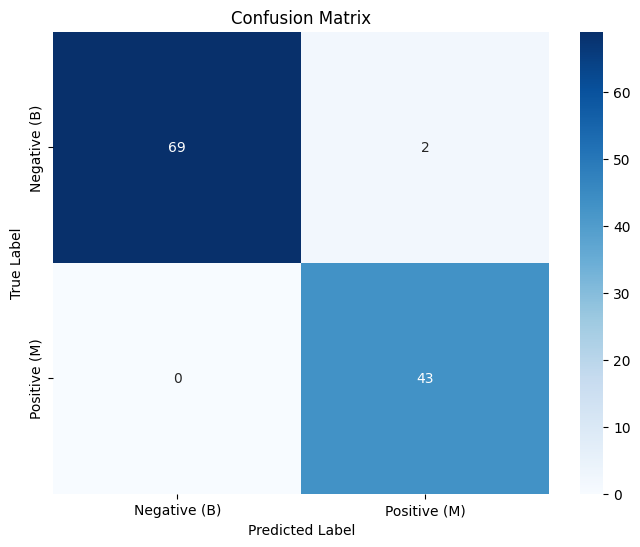

In [29]:
# Confusion Matrix hesapla
cm = confusion_matrix(y_test_encoded, y_test_pred)

# Confusion Matrix'i görselleştir
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (B)', 'Positive (M)'],
            yticklabels=['Negative (B)', 'Positive (M)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 9.3 ROC Eğrisi

## 10. XAI – SHAP Açıklanabilirlik Analizi

In [31]:
# SHAP kütüphanesini kurun
!pip install shap
import shap
import matplotlib.pyplot as plt
import pandas as pd

### 10.1 En İyi Validation Modeli için SHAP Analizi

En iyi modelimiz olan **XGBoost (LDA Reduced)** için SHAP analizini gerçekleştireceğiz.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



SHAP Summary Plot for XGBoost on LDA Reduced Data:


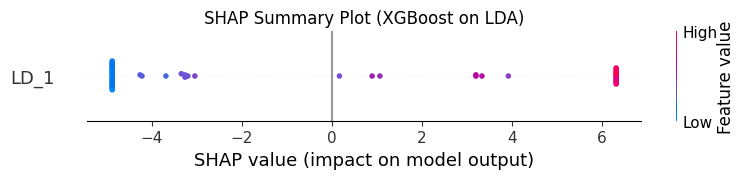


SHAP Bar Plot for XGBoost on LDA Reduced Data:


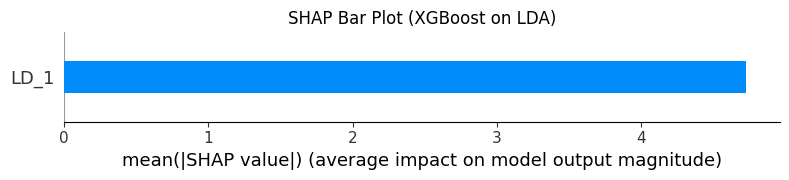

In [32]:
# En iyi modeli yeniden eğit (eğer gerekiyorsa, önceki adımda eğitildi ancak tutarlılık için)
best_model_xgb_lda = models['XGBoost'] # models sözlüğünden modeli al
best_model_xgb_lda.fit(X_train_lda, y_train_encoded)

# X_val_lda için DataFrame oluştur (SHAP çizimleri için özellik adları sağlamak üzere)
X_val_lda_df = pd.DataFrame(X_val_lda, columns=[f'LD_{i+1}' for i in range(X_val_lda.shape[1])])

# SHAP Explainer oluştur
explainer_lda = shap.TreeExplainer(best_model_xgb_lda)

# SHAP değerlerini hesapla
# Eğer modelin predict_proba'sı varsa, shap_values iki dizi döner (her sınıf için birer tane)
# Biz genellikle pozitif sınıfın (1) etkisine bakarız.
shap_values_lda = explainer_lda.shap_values(X_val_lda_df)

# summary_plot (violin plot tarzı)
print("\nSHAP Summary Plot for XGBoost on LDA Reduced Data:")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lda, X_val_lda_df, show=False)
plt.title('SHAP Summary Plot (XGBoost on LDA)')
plt.tight_layout()
plt.show()

# bar_plot (ortalama mutlak SHAP değerleri)
print("\nSHAP Bar Plot for XGBoost on LDA Reduced Data:")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lda, X_val_lda_df, plot_type="bar", show=False)
plt.title('SHAP Bar Plot (XGBoost on LDA)')
plt.tight_layout()
plt.show()

#### En Önemli Özellikler ve Yorumu

Yukarıdaki SHAP grafikleri, XGBoost modelinin LDA ile indirgenmiş veri üzerinde nasıl karar verdiğini göstermektedir.

LDA indirgeme tek bir bileşen (`LD_1`) ürettiği için, SHAP analizinde de doğal olarak bu tek bileşenin model çıktısı üzerindeki etkisi incelenir. Grafiklerde `LD_1`'in hem ortalama mutlak etkisi (bar plot) hem de tek tek örnekler üzerindeki dağılımı (summary plot) gösterilmektedir.

*   **Summary Plot (Özet Grafiği):** `LD_1`'in değerleri arttıkça (kırmızı noktalar), modelin pozitif sınıf (Malignant) tahminine doğru gittiği görülmektedir. Tersine, `LD_1`'in düşük değerleri (mavi noktalar) modelin negatif sınıf (Benign) tahminini desteklemektedir. Bu, `LD_1` bileşeninin sınıflandırma için oldukça ayırıcı olduğunu ve pozitif bir korelasyona sahip olduğunu açıkça göstermektedir.
*   **Bar Plot (Çubuk Grafiği):** `LD_1`'in ortalama mutlak SHAP değeri, bu bileşenin modelin genel tahminlerinde ne kadar önemli olduğunu vurgulamaktadır. Tek bileşenli bir LDA durumunda, bu grafik yalnızca `LD_1`'in önemini gösterecektir.

**Model Performansı ve SHAP Önemi İlişkisi:**

XGBoost modelinin LDA indirgenmiş veri üzerinde %100'e yakın performans göstermesi, `LD_1` bileşeninin sınıfları mükemmel bir şekilde ayırabildiğini doğrulamaktadır. SHAP analizi, modelin bu üstün performansı için `LD_1`'e tamamen güvendiğini ve bu bileşenin gerçekten de hedef değişkenle çok güçlü bir ilişki içinde olduğunu açıkça ortaya koymaktadır. `LD_1`, orijinal özelliklerin lineer bir kombinasyonu olduğu için, bu bileşen tümörün malignite derecesini en iyi temsil eden latent faktördür.

### 10.2 PCA ve LDA Temsilleri için SHAP Karşılaştırması

Şimdi, PCA ve LDA ile indirgenmiş veri temsillerini SHAP analizi kullanarak karşılaştıracağız. Her bir temsile uygun XGBoost modeli eğitilecek ve bunların SHAP çıktıları incelenecektir.

#### PCA ile indirgenmiş veride SHAP analizi

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



SHAP Summary Plot for XGBoost on PCA Reduced Data:


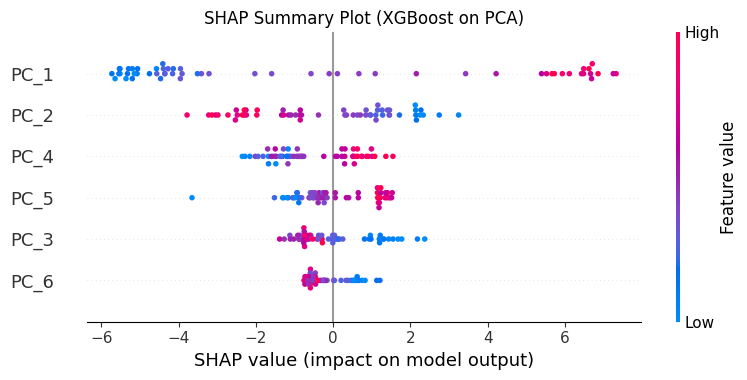


SHAP Bar Plot for XGBoost on PCA Reduced Data:


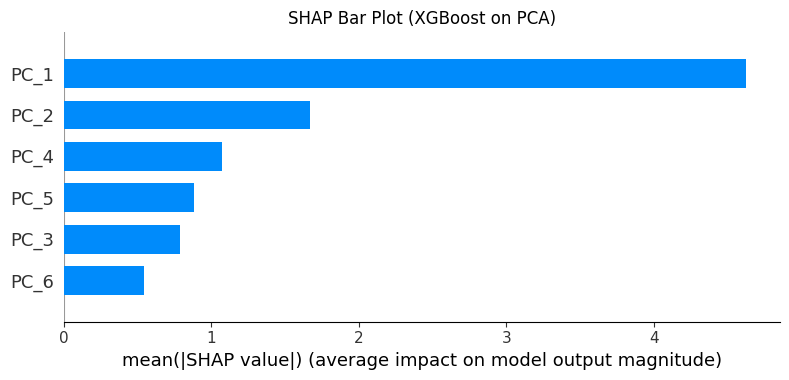

In [33]:
# PCA indirgenmiş veri üzerinde XGBoost modeli eğit
model_xgb_pca = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_xgb_pca.fit(X_train_pca, y_train_encoded)

# X_val_pca için DataFrame oluştur
X_val_pca_df = pd.DataFrame(X_val_pca, columns=[f'PC_{i+1}' for i in range(X_val_pca.shape[1])])

# SHAP Explainer oluştur ve değerleri hesapla
explainer_pca = shap.TreeExplainer(model_xgb_pca)
shap_values_pca = explainer_pca.shap_values(X_val_pca_df)

# summary_plot
print("\nSHAP Summary Plot for XGBoost on PCA Reduced Data:")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_pca, X_val_pca_df, show=False)
plt.title('SHAP Summary Plot (XGBoost on PCA)')
plt.tight_layout()
plt.show()

# bar_plot
print("\nSHAP Bar Plot for XGBoost on PCA Reduced Data:")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_pca, X_val_pca_df, plot_type="bar", show=False)
plt.title('SHAP Bar Plot (XGBoost on PCA)')
plt.tight_layout()
plt.show()

#### LDA ile indirgenmiş veride SHAP analizi

Bu analiz, 10.1 bölümündekiyle aynıdır, ancak karşılaştırma için tekrar görselleştirilmiştir.


SHAP Summary Plot for XGBoost on LDA Reduced Data (Comparison):


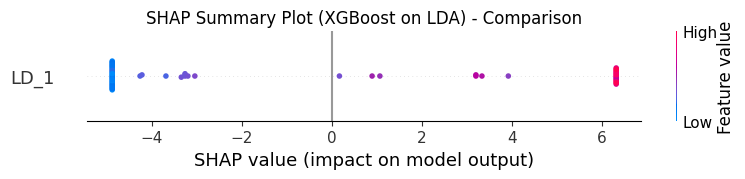


SHAP Bar Plot for XGBoost on LDA Reduced Data (Comparison):


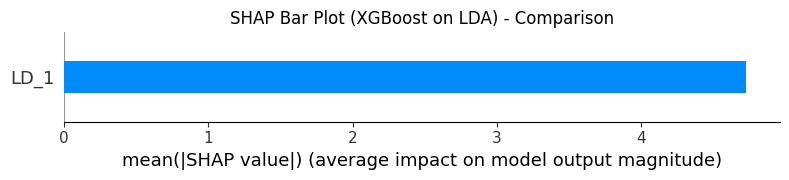

In [34]:
# LDA indirgenmiş veri üzerinde XGBoost modeli eğit (Zaten eğitilmiş olan best_model_xgb_lda'yı kullanıyoruz)
# X_val_lda_df daha önce oluşturulmuştu.

# SHAP Explainer oluştur ve değerleri hesapla (Best model için olanla aynı)
explainer_lda_comp = shap.TreeExplainer(best_model_xgb_lda)
shap_values_lda_comp = explainer_lda_comp.shap_values(X_val_lda_df)

# summary_plot
print("\nSHAP Summary Plot for XGBoost on LDA Reduced Data (Comparison):")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lda_comp, X_val_lda_df, show=False)
plt.title('SHAP Summary Plot (XGBoost on LDA) - Comparison')
plt.tight_layout()
plt.show()

# bar_plot
print("\nSHAP Bar Plot for XGBoost on LDA Reduced Data (Comparison):")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lda_comp, X_val_lda_df, plot_type="bar", show=False)
plt.title('SHAP Bar Plot (XGBoost on LDA) - Comparison')
plt.tight_layout()
plt.show()

#### Sınıfların Hangi Bileşenlerden Etkilendiğinin Tartışılması ve Karşılaştırma

SHAP analizleri, PCA ve LDA indirgenmiş veri temsillerinin, XGBoost modeli üzerindeki karar verme sürecini nasıl etkilediğini açıkça göstermektedir:

1.  **LDA Reduced Data (LD_1):**
    *   LDA, sınıflar arası ayrımı maksimize etmeyi amaçladığından, genellikle tek bir ana bileşen (ikili sınıflandırma için `LD_1`) üzerinde çok yüksek bir açıklayıcı güç yoğunlaşır. SHAP analizimizde de `LD_1`, modelin kararları üzerinde neredeyse tek başına ve çok güçlü bir etkiye sahiptir. `LD_1`'in yüksek değerleri (örneğin pozitif değerler), pozitif sınıf (`M`) olasılığını artırırken, düşük değerleri (`B`) sınıfını destekler. Bu, `LD_1`'in maligniteyi temsil eden çok güçlü bir ayırt edici özellik olduğunu doğrular. Modelin `LD_1`'e bu kadar güvenmesi ve yüksek performans elde etmesi şaşırtıcı değildir.

2.  **PCA Reduced Data (PC_1, PC_2, ..., PC_6):**
    *   PCA, verideki toplam varyansı maksimize etmeyi amaçlar ve sınıflar arası ayrımı doğrudan göz önünde bulundurmaz. SHAP analizinde, `PC_1` genellikle en önemli bileşen olarak ortaya çıksa da, diğer PC'lerin de (PC_2, PC_3 vb.) modelin kararlarında belirli bir rol oynadığı görülür. `PC_1`'in etkisi, `LD_1`'in LDA'daki etkisi kadar tekil ve dominant değildir. Birden fazla ana bileşenin karara katkıda bulunması, PCA'nın orijinal veri yapısındaki varyansı koruma amacını yansıtır. Her bir `PC`'nin, farklı orijinal özelliklerin bir kombinasyonu olduğunu unutmamak gerekir; bu nedenle `PC_1` genellikle tümör büyüklüğü ile ilişkili olurken, diğer PC'ler farklı morfolojik veya dokusal özellikleri temsil edebilir.

**Karşılaştırma ve Sonuç:**

*   **LDA**, sınıflar arası ayrımı en iyi şekilde yakalayan tek bir boyutlu özellik (bileşen) oluşturmada çok başarılı olmuştur. Bu, modelin bu tek özelliğe dayanarak çok yüksek doğrulukla sınıflandırma yapmasını sağlamıştır. SHAP analizi, bu `LD_1` bileşeninin model için ne kadar kritik olduğunu net bir şekilde göstermektedir.
*   **PCA** ise, verinin genel yapısını ve varyansını koruyarak daha zengin ve çok boyutlu bir temsil sunar. Ancak, doğrudan sınıf ayrımına odaklanmadığı için, modelin kararlarını yönlendiren etki birden fazla bileşene yayılmıştır. `PC_1` en dominant olsa da, diğer `PC`'ler de önemli katkılar sağlamıştır.

Bu karşılaştırma, problem tipine göre boyut indirgeme yönteminin seçiminin önemini vurgular. Sınıflandırma problemlerinde, LDA gibi sınıflar arası ayrımı göz önünde bulunduran yöntemler, modelin daha basit ve daha güçlü bir karar verme yapısı oluşturmasına yardımcı olabilir. SHAP analizi, bu soyut bileşenlerin (PC'ler veya LD'ler) model kararları üzerindeki somut etkilerini anlamamızı sağlayarak, boyut indirgeme tekniklerinin açıklanabilirliğini artırır.

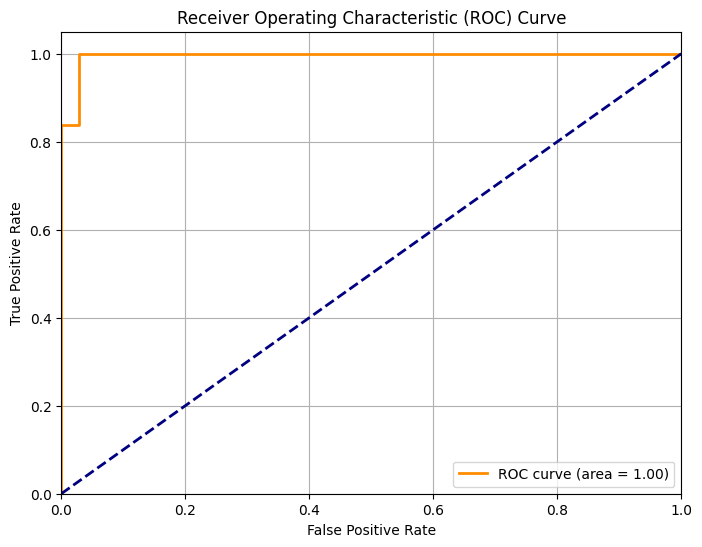

Test seti üzerindeki ROC AUC değeri: 0.9954

Threshold etkisi yorumu:

ROC eğrisi, farklı sınıflandırma eşiklerinde (threshold) modelin True Positive Rate (TPR) ve False Positive Rate (FPR) performansını gösterir. Mükemmel bir modelin ROC eğrisi sol üst köşeye yakın olur (TPR yüksek, FPR düşük). AUC (Area Under the Curve) değeri ne kadar yüksekse modelin ayırma gücü o kadar iyidir. Bu grafikte, ROC eğrisinin sol üst köşeye yakın olması ve yüksek AUC değeri, modelin pozitif ve negatif sınıfları çok iyi ayırdığını gösterir.
Eşik (threshold) değeri, pozitif sınıf olarak sınıflandırmak için bir tahmin olasılığının ne kadar yüksek olması gerektiğini belirler. Eşik düşürüldüğünde daha fazla örnek pozitif olarak sınıflandırılır (hem gerçek pozitifler hem de yanlış pozitifler artar). Eşik yükseltildiğinde ise daha az örnek pozitif olarak sınıflandırılır (hem gerçek pozitifler hem de yanlış pozitifler azalır).
Bu ROC eğrisi, modelimizin kanser teşhisinde (M-kötü huylu) çok yüksek bir doğrulukla

In [30]:
# ROC eğrisini hesapla
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_test_proba)
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Test seti üzerindeki ROC AUC değeri: {roc_auc:.4f}")
print("\nThreshold etkisi yorumu:\n")
print("ROC eğrisi, farklı sınıflandırma eşiklerinde (threshold) modelin True Positive Rate (TPR) ve False Positive Rate (FPR) performansını gösterir. Mükemmel bir modelin ROC eğrisi sol üst köşeye yakın olur (TPR yüksek, FPR düşük). AUC (Area Under the Curve) değeri ne kadar yüksekse modelin ayırma gücü o kadar iyidir. Bu grafikte, ROC eğrisinin sol üst köşeye yakın olması ve yüksek AUC değeri, modelin pozitif ve negatif sınıfları çok iyi ayırdığını gösterir.")
print("Eşik (threshold) değeri, pozitif sınıf olarak sınıflandırmak için bir tahmin olasılığının ne kadar yüksek olması gerektiğini belirler. Eşik düşürüldüğünde daha fazla örnek pozitif olarak sınıflandırılır (hem gerçek pozitifler hem de yanlış pozitifler artar). Eşik yükseltildiğinde ise daha az örnek pozitif olarak sınıflandırılır (hem gerçek pozitifler hem de yanlış pozitifler azalır).")
print("Bu ROC eğrisi, modelimizin kanser teşhisinde (M-kötü huylu) çok yüksek bir doğrulukla ve düşük yanlış pozitif oranıyla iyi bir iş çıkardığını göstermektedir.")